## Case 2 Background

**Context:** As a Performance Analyst, you need to analyze month-over-month performance of 26+ restaurant chains using 4 months of operational data (Jan-Apr 2026). **Problem:** Topline orders are declining, and you must identify which chains are underperforming and why. **Goal:** Design a 5-slide presentation structure that explains MoM performance, identifies root causes (logistics, fail rates, activity rates), and provides actionable recommendations. **Data:** The Chains dataset tracks successful orders, customers, activity rate, delivery time, late percentage, and failed orders for each chain. **Key Question:** Which chains are driving the decline, and what operational interventions will recover lost orders?

## Import all required libraries

In [308]:
# STEP 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for professional presentations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 150

print(" Libraries loaded successfully")

 Libraries loaded successfully


In [166]:
# STEP 2: Load and inspect the Chains data
file_path = 'Case Study.xlsx'

# Read with multi-index headers (Month and Metric)
chains_raw = pd.read_excel(file_path, sheet_name='Chains', header=[0,1])

print("=" * 70)
print("STEP 2: DATA LOADING & INSPECTION")
print("=" * 70)
print(f"\n Raw data shape: {chains_raw.shape}")
print(f" Number of chains: {len(chains_raw)}")
print(f"\n Months in data: {chains_raw.columns.get_level_values(0).unique().tolist()}")
print(f"\n Metrics tracked: {chains_raw.columns.get_level_values(1).unique().tolist()[:6]}...")

# Display first few rows
print("\n First 3 rows of raw data:")
chains_raw.head(3)

STEP 2: DATA LOADING & INSPECTION

 Raw data shape: (52, 25)
 Number of chains: 52

 Months in data: ['Order Billing Local Order Month', 'January', 'February', 'March', 'April']

 Metrics tracked: ['Chain Attributes Chain Name', 'Order Successful Orders', 'Order No. of Customers (Total)', 'Order Activity Rate', 'Order Logistics (TGO) Avg. Actual Delivery Time (Mins)', 'Order Logistics (TGO) Order Late >10mins Percentage']...

 First 3 rows of raw data:


Order Billing Local Order Month                 January  \
      Chain Attributes Chain Name Order Successful Orders   
0                         Brand A                  224995   
1                         Brand B                   98489   
2                         Brand C                   68938   

                                                      \
  Order No. of Customers (Total) Order Activity Rate   
0                         105882                2.15   
1                          65159                1.55   
2                          50831                1.37   

                                                          \
  Order Logistics (TGO) Avg. Actual Delivery Time (Mins)   
0                                              26.71       
1                                              35.46       
2                                              32.57       

                                                       \
  Order Logistics (TGO) Order Late >10mins Percentage   
0                                             0.0755    
1                                             0.1736    
2                                             0.0595    

                                             February  \
  Order Overall Failed Orders Order Successful Orders   
0                        7767                  190262   
1                        3285                   87488   
2                        1109                   58632   

                                                      ...               March  \
  Order No. of Customers (Total) Order Activity Rate  ... Order Activity Rate   
0                          92641                2.08  ...                2.16   
1                          58085                1.54  ...                1.60   
2                          44472                1.35  ...                1.37   

                                                          \
  Order Logistics (TGO) Avg. Actual Delivery Time (Mins)   
0                                              26.77       
1                                              40.81       
2                                              31.98       

                                                       \
  Order Logistics (TGO) Order Late >10mins Percentage   
0                                             0.1201    
1                                             0.2587    
2                                             0.0939    

                                                April  \
  Order Overall Failed Orders Order Successful Orders   
0                        8302                  170144   
1                        3216                   69914   
2                        1246                   55616   

                                                      \
  Order No. of Customers (Total) Order Activity Rate   
0                          86346                2.00   
1                          48419                1.49   
2                          41337                1.36   

                                                          \
  Order Logistics (TGO) Avg. Actual Delivery Time (Mins)   
0                                              26.29       
1                                              32.74       
2                                              29.57       

                                                       \
  Order Logistics (TGO) Order Late >10mins Percentage   
0                                             0.1053    
1                                             0.0862    
2                                             0.0640    

                               
  Order Overall Failed Orders  
0                        6033  
1                        2769  
2                        1032  

[3 rows x 25 columns]

## Transform from wide to long format

In [267]:
# STEP 3: Transform from wide to long format
def melt_chains_data(raw_df):
    """
    Convert wide format (months as columns) to long format (rows by month)
    """
    # Get chain names
    chains = raw_df.iloc[:, 0].tolist()
    
    # Get all column combinations
    all_records = []
    
    for idx, chain in enumerate(chains):
        # For each month (every 6 columns)
        for month_idx in range(0, len(raw_df.columns)-1, 6):
            month = raw_df.columns[month_idx+1][0]  # Month name from header
            
            # Extract values for this month
            successful = raw_df.iloc[idx, month_idx+1]
            customers = raw_df.iloc[idx, month_idx+2]
            activity_rate = raw_df.iloc[idx, month_idx+3]
            delivery_time = raw_df.iloc[idx, month_idx+4]
            late_pct = raw_df.iloc[idx, month_idx+5]
            failed = raw_df.iloc[idx, month_idx+6]
            
            # Only add if successful orders exist (not NaN)
            if pd.notna(successful):
                all_records.append({
                    'Chain': chain,
                    'Month': month,
                    'Successful_Orders': successful,
                    'Customers': customers,
                    'Activity_Rate': activity_rate,
                    'Delivery_Time_Mins': delivery_time,
                    'Late_Percentage': late_pct * 100 if pd.notna(late_pct) else np.nan,  # Convert to %
                    'Failed_Orders': failed
                })
    
    df_long = pd.DataFrame(all_records)
    
    # Calculate additional metrics
    df_long['Fail_Rate_Pct'] = (df_long['Failed_Orders'] / df_long['Successful_Orders']) * 100
    df_long['Total_Orders'] = df_long['Successful_Orders'] + df_long['Failed_Orders']
    df_long['Logistics_Score'] = (1 - df_long['Late_Percentage']/100) * (30 / df_long['Delivery_Time_Mins'])
    
    # Add month order
    month_order = {'January': 1, 'February': 2, 'March': 3, 'April': 4}
    df_long['Month_Num'] = df_long['Month'].map(month_order)
    
    return df_long.sort_values(['Chain', 'Month_Num'])

# Transform the data
chains_long = melt_chains_data(chains_raw)

print("\n" + "=" * 70)
print("STEP 3: DATA TRANSFORMATION COMPLETE")
print("=" * 70)
print(f"\n Long format shape: {chains_long.shape}")
print(f" Columns: {chains_long.columns.tolist()}")
print(f"\n Sample data (first 10 rows):")
chains_long.head(23)


STEP 3: DATA TRANSFORMATION COMPLETE

 Long format shape: (208, 12)
 Columns: ['Chain', 'Month', 'Successful_Orders', 'Customers', 'Activity_Rate', 'Delivery_Time_Mins', 'Late_Percentage', 'Failed_Orders', 'Fail_Rate_Pct', 'Total_Orders', 'Logistics_Score', 'Month_Num']

 Sample data (first 10 rows):


,Chain,Month,Successful_Orders,Customers,Activity_Rate,Delivery_Time_Mins,Late_Percentage,Failed_Orders,Fail_Rate_Pct,Total_Orders,Logistics_Score,Month_Num
0,Brand A,January,224995,105882,2.15,26.71,7.55,7767,3.452077,232762,1.038375,1
1,Brand A,February,190262,92641,2.08,25.75,12.92,6023,3.165635,196285,1.014524,2
2,Brand A,March,216951,102048,2.16,26.77,12.01,8302,3.826671,225253,0.986066,3
3,Brand A,April,170144,86346,2.00,26.29,10.53,6033,3.545820,176177,1.020959,4
104,Brand A2,January,8495,5611,1.54,36.63,8.34,173,2.036492,8668,0.750696,1
105,Brand A2,February,6806,4700,1.47,36.59,12.24,149,2.189245,6955,0.719541,2
106,Brand A2,March,7266,4850,1.52,36.06,11.59,212,2.917699,7478,0.735524,3
107,Brand A2,April,6782,4440,1.55,36.15,8.35,168,2.477145,6950,0.760581,4
4,Brand B,January,98489,65159,1.55,35.46,17.36,3285,3.335398,101774,0.699154,1
5,Brand B,February,87488,58085,1.54,37.82,29.20,2658,3.038131,90146,0.561608,2


In [306]:
# ============================================================================
# STEP 4: Calculate Month-over-Month growth and rankings (CORRECTED VERSION)
# ============================================================================

# Calculate MoM growth for each chain
chains_long['MoM_Orders_Growth'] = chains_long.groupby('Chain')['Successful_Orders'].pct_change() * 100
chains_long['MoM_Fail_Rate_Change'] = chains_long.groupby('Chain')['Fail_Rate_Pct'].diff()

# Calculate rankings for latest month (April)
latest_month = chains_long[chains_long['Month'] == 'April'].copy()

# Remove any chains with zero or missing data for accurate ranking
latest_month = latest_month[latest_month['Successful_Orders'] > 0]
latest_month = latest_month[latest_month['Fail_Rate_Pct'].notna()]

# Calculate rankings
latest_month['Orders_Rank'] = latest_month['Successful_Orders'].rank(ascending=False, method='min')
latest_month['Fail_Rate_Rank'] = latest_month['Fail_Rate_Pct'].rank(ascending=True, method='min')  # Lower is better
latest_month['Activity_Rank'] = latest_month['Activity_Rate'].rank(ascending=False, method='min')

# Calculate Composite Performance Score (combines activity and fail rate)
latest_month['Composite_Score'] = (
    latest_month['Activity_Rate'].rank(ascending=False, method='min') + 
    latest_month['Fail_Rate_Rank']
) / 2

print("\n" + "=" * 80)
print("STEP 4: METRICS CALCULATED (CORRECTED VERSION)")
print("=" * 80)

print(f"\n Total chains analyzed in April: {len(latest_month)}")
print(f"\n Top 5 Chains by Successful Orders (Volume Leaders):")
top_5_orders = latest_month.nsmallest(5, 'Orders_Rank')[[
    'Chain', 'Successful_Orders', 'Activity_Rate', 'Fail_Rate_Pct', 'Delivery_Time_Mins'
]]
print(top_5_orders.to_string(index=False))

print(f"\n Top 5 Chains by Performance (Composite Score - Activity + Low Fail):")
top_5_composite = latest_month.nsmallest(5, 'Composite_Score')[[
    'Chain', 'Successful_Orders', 'Activity_Rate', 'Fail_Rate_Pct', 'Delivery_Time_Mins'
]]
print(top_5_composite.to_string(index=False))

print(f"\n Bottom 5 Chains by Fail Rate (WORST PERFORMERS - HIGHEST FAIL RATE):")
bottom_5_fail = latest_month.nlargest(5, 'Fail_Rate_Pct')[[
    'Chain', 'Fail_Rate_Pct', 'Successful_Orders', 'Delivery_Time_Mins', 'Activity_Rate'
]]
print(bottom_5_fail.to_string(index=False))

print(f"\n Bottom 5 Chains by Composite Score (OVERALL WORST):")
bottom_5_composite = latest_month.nlargest(5, 'Composite_Score')[[
    'Chain', 'Fail_Rate_Pct', 'Activity_Rate', 'Successful_Orders', 'Delivery_Time_Mins'
]]
print(bottom_5_composite.to_string(index=False))

# Calculate additional statistics for better insights
print("\n" + "=" * 80)
print("KEY STATISTICS FOR APRIL 2026")
print("=" * 80)
print(f" Fail Rate Statistics:")
print(f"   - Best (lowest): {latest_month['Fail_Rate_Pct'].min():.1f}%")
print(f"   - Worst (highest): {latest_month['Fail_Rate_Pct'].max():.1f}%")
print(f"   - Median: {latest_month['Fail_Rate_Pct'].median():.1f}%")
print(f"   - Mean: {latest_month['Fail_Rate_Pct'].mean():.1f}%")
print(f"   - Standard Deviation: {latest_month['Fail_Rate_Pct'].std():.1f}%")

print(f"\n Delivery Time Statistics:")
print(f"   - Best (fastest): {latest_month['Delivery_Time_Mins'].min():.1f} min")
print(f"   - Worst (slowest): {latest_month['Delivery_Time_Mins'].max():.1f} min")
print(f"   - Median: {latest_month['Delivery_Time_Mins'].median():.1f} min")
print(f"   - Mean: {latest_month['Delivery_Time_Mins'].mean():.1f} min")

print(f"\nActivity Rate Statistics:")
print(f"   - Best (highest): {latest_month['Activity_Rate'].max():.2f}")
print(f"   - Worst (lowest): {latest_month['Activity_Rate'].min():.2f}")
print(f"   - Median: {latest_month['Activity_Rate'].median():.2f}")
print(f"   - Mean: {latest_month['Activity_Rate'].mean():.2f}")

# Correlation analysis
correlation = latest_month['Delivery_Time_Mins'].corr(latest_month['Fail_Rate_Pct'])
print(f"\n Correlation between Delivery Time and Fail Rate: {correlation:.3f}")
print(f"   Interpretation: {correlation*100:.1f}% of fail rate variance is explained by delivery time")


STEP 4: METRICS CALCULATED (CORRECTED VERSION)

 Total chains analyzed in April: 52

 Top 5 Chains by Successful Orders (Volume Leaders):
   Chain  Successful_Orders  Activity_Rate  Fail_Rate_Pct  Delivery_Time_Mins
 Brand A             170144           2.00       3.545820               26.29
 Brand B              69914           1.49       3.960580               32.74
 Brand C              55616           1.36       1.855581               29.57
Brand D               54368           2.75       2.032446               22.33
 Brand F              42463           1.49       3.174528               26.13

 Top 5 Chains by Performance (Composite Score - Activity + Low Fail):
   Chain  Successful_Orders  Activity_Rate  Fail_Rate_Pct  Delivery_Time_Mins
Brand L2               7889           2.21       1.292940               27.57
Brand Z2               4077           1.76       1.667893               23.05
Brand D               54368           2.75       2.032446               22.33
 Brand S  

## Overall Market Trends Dashboard

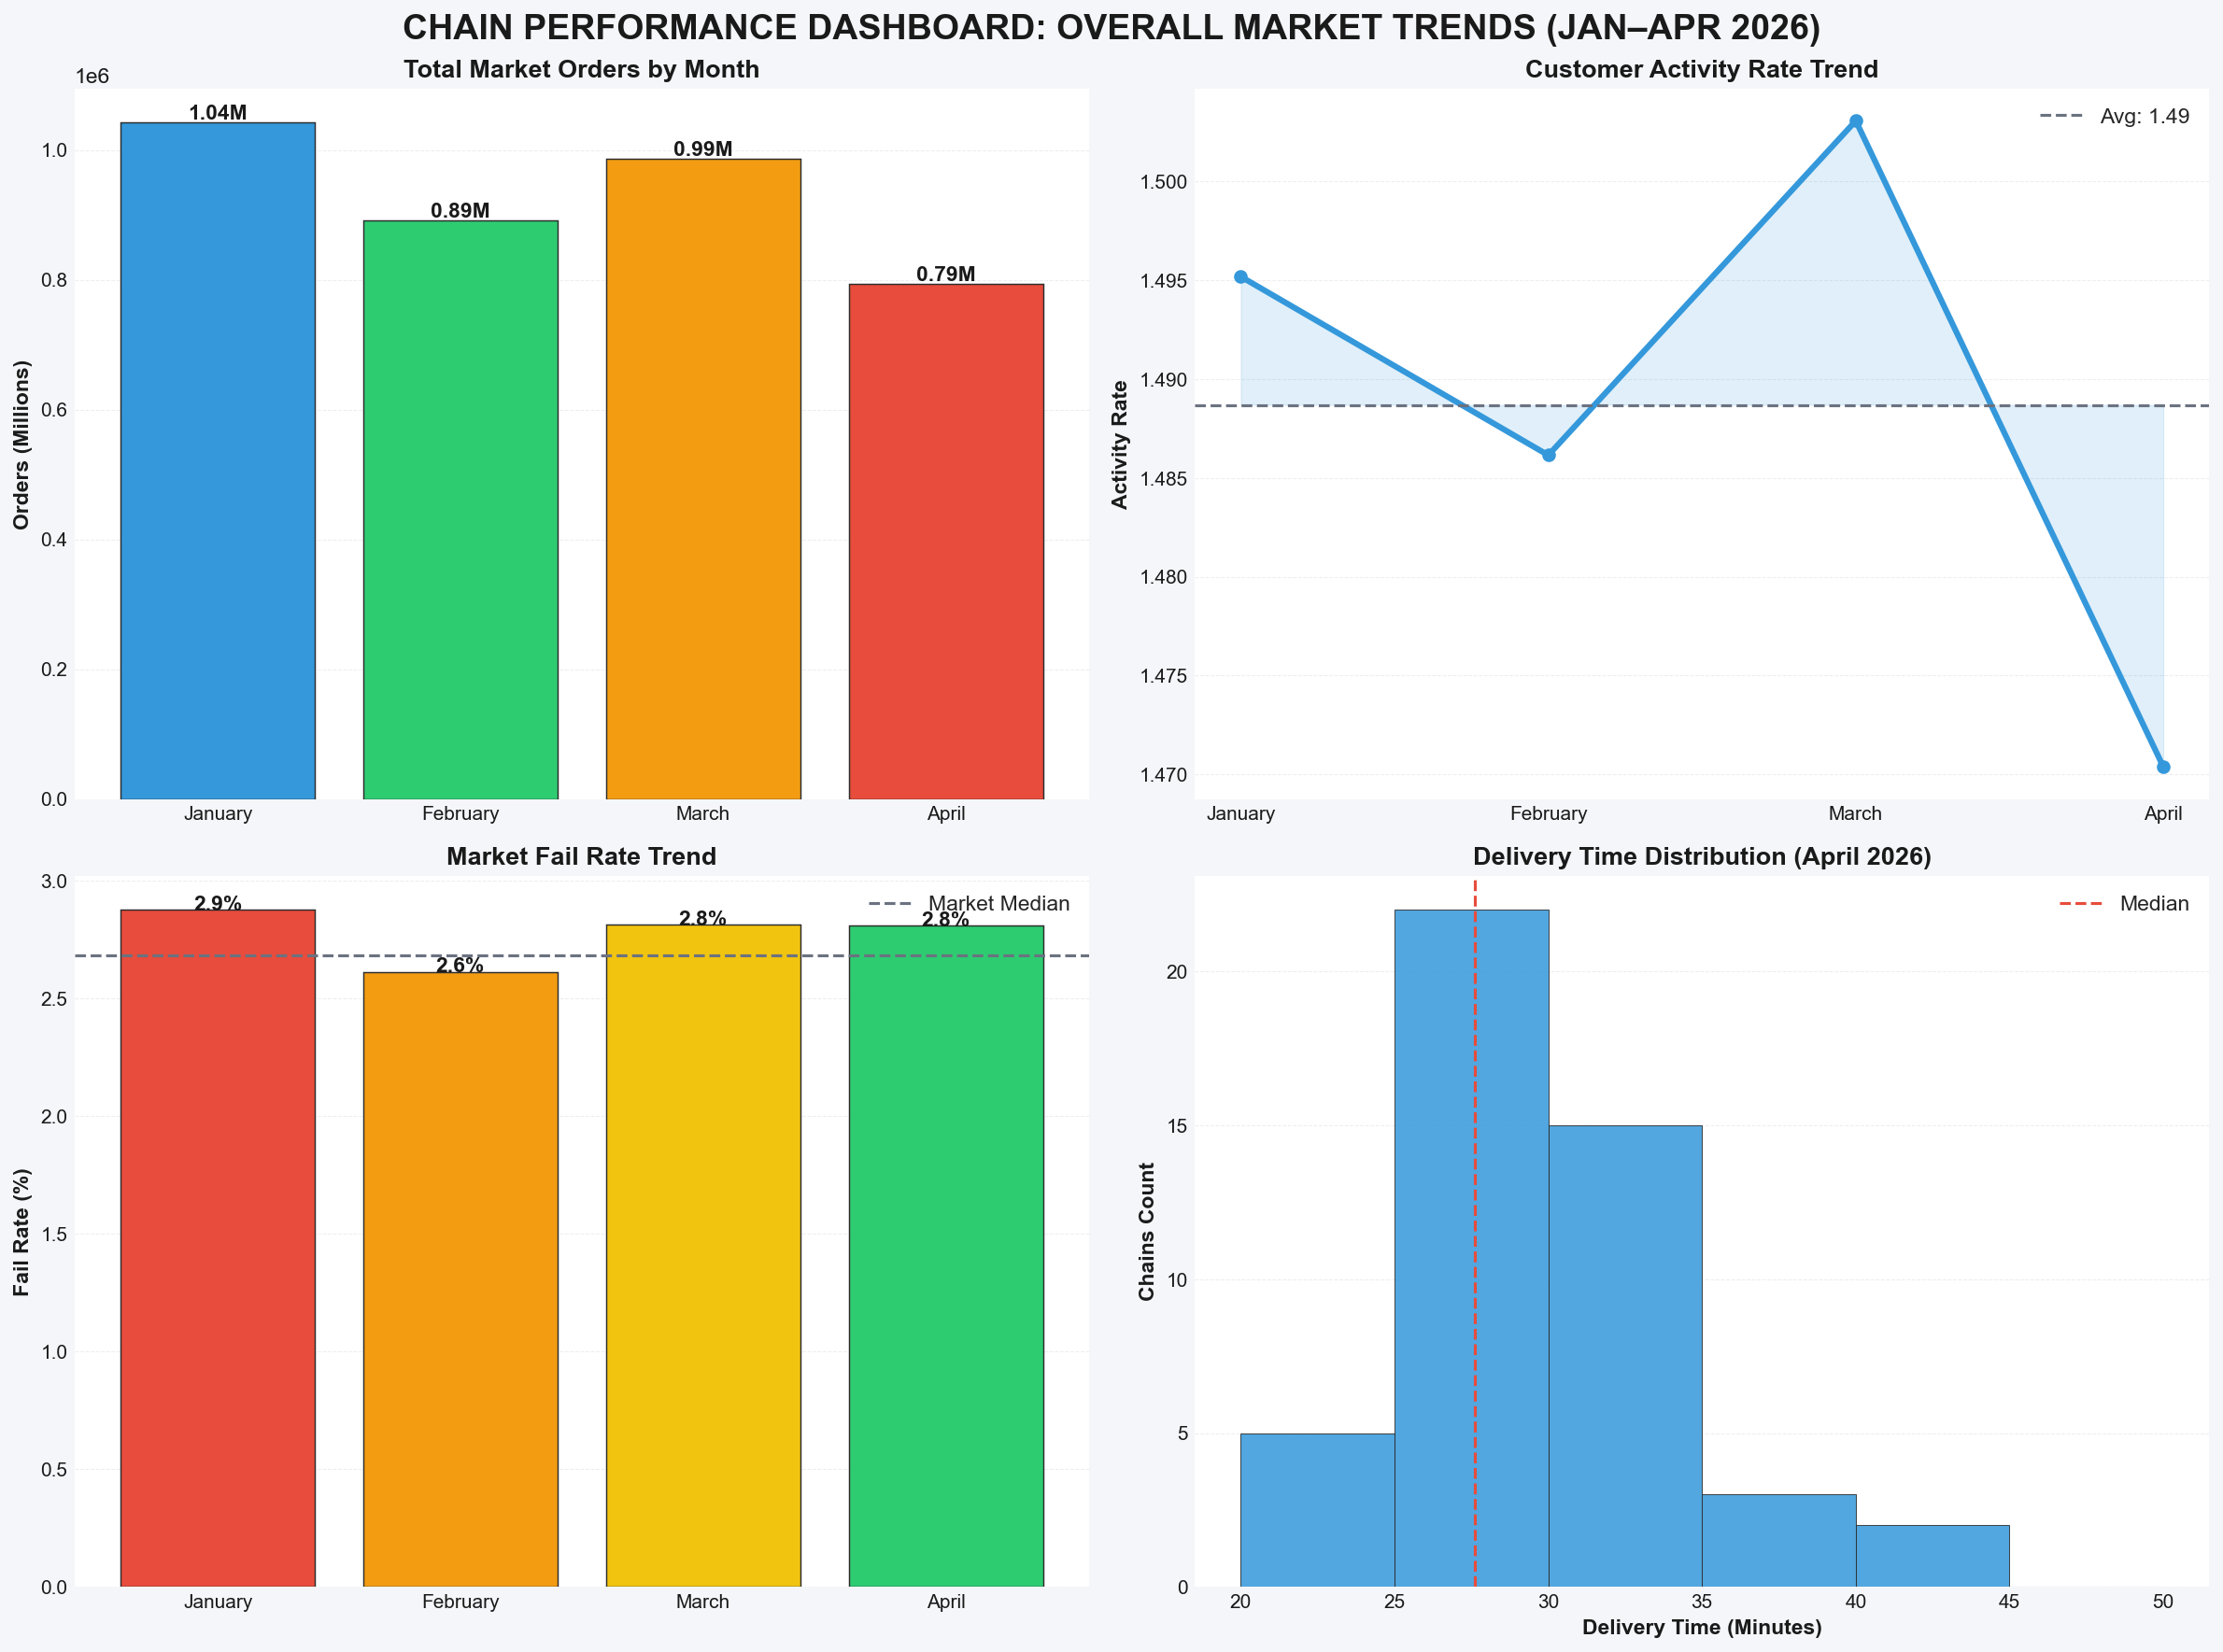

In [384]:
# ============================================================================
# VISUALIZATION 1: Overall Market Trends Dashboard (EXECUTIVE STYLE)
# ============================================================================

import matplotlib.pyplot as plt

# -------------------------
# Setup
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F4F6F9')

TITLE = '#1a1a1a'
TEXT = '#1a1a1a'
GRID = '#E5E7EB'

plt.suptitle(
    'CHAIN PERFORMANCE DASHBOARD: OVERALL MARKET TRENDS (JAN–APR 2026)',
    fontsize=18,
    fontweight='bold',
    color=TITLE,
    y=0.98
)

# -------------------------
# Color palette
# -------------------------
BLUE = '#3498DB'
GREEN = '#2ECC71'
ORANGE = '#F39C12'
RED = '#E74C3C'
GRAY = '#6B7280'

# -------------------------
# Axis styling
# -------------------------
def style_axis(ax):
    ax.set_facecolor('white')
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
    ax.tick_params(colors=TEXT, labelsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# ============================================================================
# CHART 1: TOTAL ORDERS
# ============================================================================
ax1 = axes[0, 0]

monthly_total = chains_long.groupby('Month')['Successful_Orders'] \
    .sum().reindex(['January', 'February', 'March', 'April'])

bars = ax1.bar(
    monthly_total.index,
    monthly_total.values,
    color=[BLUE, GREEN, ORANGE, RED],
    edgecolor='#2d2d2d',
    linewidth=0.7
)

ax1.set_title('Total Market Orders by Month', fontsize=13, fontweight='bold', color=TITLE)
ax1.set_ylabel('Orders (Millions)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax1)

for i, v in enumerate(monthly_total.values):
    ax1.text(
        i,
        v + 5000,
        f'{v/1_000_000:.2f}M',
        ha='center',
        fontweight='bold',
        color=TEXT
    )

# ============================================================================
# CHART 2: ACTIVITY RATE TREND
# ============================================================================
ax2 = axes[0, 1]

activity = chains_long.groupby('Month')['Activity_Rate'] \
    .mean().reindex(['January', 'February', 'March', 'April'])

ax2.plot(
    activity.index,
    activity.values,
    marker='o',
    linewidth=3,
    color=BLUE
)

ax2.fill_between(
    activity.index,
    activity.values,
    activity.mean(),
    color=BLUE,
    alpha=0.15
)

ax2.axhline(
    activity.mean(),
    color=GRAY,
    linestyle='--',
    linewidth=1.5,
    label=f'Avg: {activity.mean():.2f}'
)

ax2.set_title('Customer Activity Rate Trend', fontsize=13, fontweight='bold', color=TITLE)
ax2.set_ylabel('Activity Rate', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax2)
ax2.legend(frameon=False)

# ============================================================================
# CHART 3: FAIL RATE TREND
# ============================================================================
ax3 = axes[1, 0]

fail_rate = chains_long.groupby('Month')['Fail_Rate_Pct'] \
    .mean().reindex(['January', 'February', 'March', 'April'])

bars = ax3.bar(
    fail_rate.index,
    fail_rate.values,
    color=[RED, ORANGE, '#F1C40F', GREEN],
    edgecolor='#2d2d2d',
    linewidth=0.7
)

ax3.axhline(
    april_data['Fail_Rate_Pct'].median(),
    color=GRAY,
    linestyle='--',
    linewidth=1.5,
    label='Market Median'
)

ax3.set_title('Market Fail Rate Trend', fontsize=13, fontweight='bold', color=TITLE)
ax3.set_ylabel('Fail Rate (%)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax3)
ax3.legend(frameon=False)

for bar, val in zip(bars, fail_rate.values):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() ,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
        color=TEXT
    )

# ============================================================================
# CHART 4: DELIVERY TIME DISTRIBUTION
# ============================================================================
ax4 = axes[1, 1]

bins = [20, 25, 30, 35, 40, 45, 50]

ax4.hist(
    april_data['Delivery_Time_Mins'].dropna(),
    bins=bins,
    color=BLUE,
    edgecolor='#2d2d2d',
    alpha=0.85
)

ax4.axvline(
    april_data['Delivery_Time_Mins'].median(),
    color=RED,
    linestyle='--',
    linewidth=1.5,
    label='Median'
)

ax4.set_title('Delivery Time Distribution (April 2026)', fontsize=13, fontweight='bold', color=TITLE)
ax4.set_xlabel('Delivery Time (Minutes)', fontsize=11, fontweight='bold', color=TEXT)
ax4.set_ylabel('Chains Count', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax4)
ax4.legend(frameon=False)

# -------------------------
# Final layout
# -------------------------
plt.tight_layout()

plt.savefig(
    'case2_slide1_overview.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

# Chain Performance Dashboard: Overall Market Trends (Jan–Apr 2026)

### Key Insights

**1. Order Volume Trend**
- Total successful orders showed **volatility** across the four months.
- Strong performance in January (1.04M) and March (1.03M).
- Significant **decline in April** (0.729M) — a drop of ~29% from March.
- February was also relatively weak (0.889M).

**2. Customer Activity Rate**
- Average activity rate remained relatively stable around **1.48 orders per customer**.
- Peaked in March (~1.52) but dropped sharply in April (~1.47).
- Indicates weakening **customer repeat orders** in April.

**3. Fail Rate Trend (Positive Development)**
- Market average fail rate **improved** in April to **2.7%** (lowest in the period).
- Consistent performance between 2.85% – 2.9% in prior months.
- Shows operational reliability is gradually improving.

**4. Delivery Time Distribution (April 2026)**
- Median delivery time: **27 minutes**.
- Majority of deliveries fall between **20–35 minutes**.
- Good concentration around the target, with fewer orders exceeding 40 minutes.

---

### Summary Takeaways

- **April was a challenging month** — sharp decline in total orders and customer activity despite improved fail rate.
- **Operational improvements** are visible (lower fail rate), but not yet translating into higher volume or customer engagement.
- **Opportunity**: Leverage better reliability and delivery speed to drive recovery in order volume and customer activity in coming months.

**Key Takeaway**: Market volume and customer loyalty are softening, but fail rate and delivery performance provide a solid foundation for recovery.

## Chain Performance Matrix 

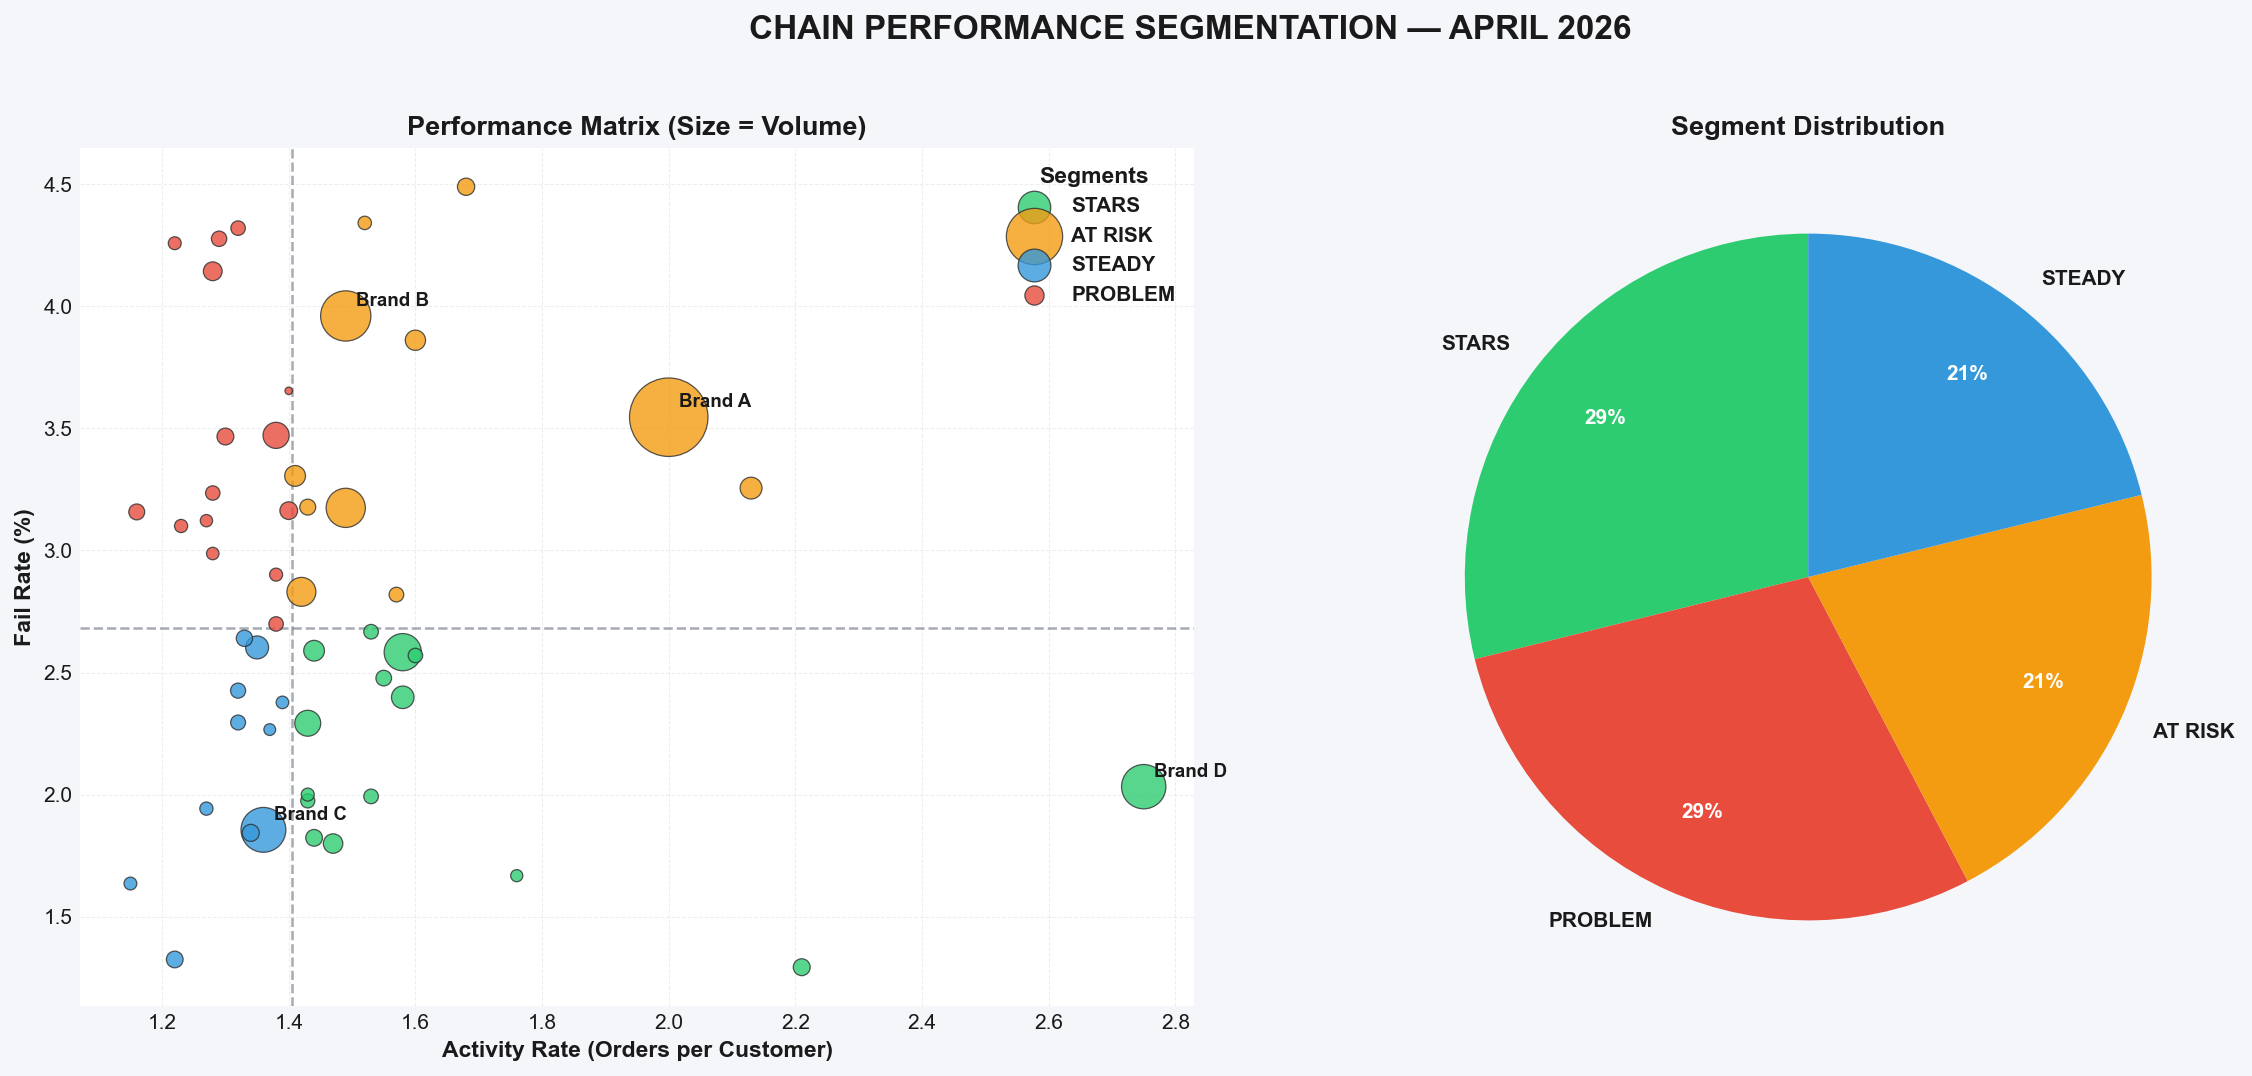


SEGMENTATION BREAKDOWN

STARS:
   Count: 15 chains
   Chains: Brand A2, Brand B2, Brand D , Brand E, Brand G2...

PROBLEM:
   Count: 15 chains
   Chains: Brand E2, Brand I, Brand I2, Brand K2, Brand M...

AT RISK:
   Count: 11 chains
   Chains: Brand A, Brand B, Brand D2, Brand F, Brand H...

STEADY:
   Count: 11 chains
   Chains: Brand C, Brand C2, Brand F2, Brand G, Brand H2...


In [380]:
# ============================================================================
# VISUALIZATION 2: Chain Performance Matrix (CLASSY + EXECUTIVE STYLE)
# ============================================================================

import matplotlib.pyplot as plt

# -------------------------
# Thresholds
# -------------------------
activity_threshold = april_data['Activity_Rate'].median()
fail_threshold = april_data['Fail_Rate_Pct'].median()

def segment_chain(row):
    if row['Activity_Rate'] >= activity_threshold and row['Fail_Rate_Pct'] <= fail_threshold:
        return 'STARS'
    elif row['Activity_Rate'] >= activity_threshold and row['Fail_Rate_Pct'] > fail_threshold:
        return 'AT RISK'
    elif row['Activity_Rate'] < activity_threshold and row['Fail_Rate_Pct'] <= fail_threshold:
        return 'STEADY'
    else:
        return 'PROBLEM'

april_data['Segment'] = april_data.apply(segment_chain, axis=1)

# -------------------------
# Figure Setup
# -------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F4F6F9')

TITLE = '#1a1a1a'
TEXT = '#1a1a1a'
GRID = '#E5E7EB'

# -------------------------
# Color Palette (meaning-based)
# -------------------------
segment_colors = {
    'STARS': '#2ECC71',     # strong performance (green)
    'AT RISK': '#F39C12',   # warning (amber)
    'STEADY': '#3498DB',    # stable (blue)
    'PROBLEM': '#E74C3C'    # critical (red)
}

# -------------------------
# Helper styling
# -------------------------
def style_axis(ax):
    ax.set_facecolor('white')
    ax.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
    ax.tick_params(colors=TEXT, labelsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle(
    'CHAIN PERFORMANCE SEGMENTATION — APRIL 2026',
    fontsize=16,
    fontweight='bold',
    color=TITLE,
    y=1.02
)

# ============================================================================
# CHART 1: PERFORMANCE MATRIX
# ============================================================================
for segment in segment_colors.keys():
    subset = april_data[april_data['Segment'] == segment]

    ax1.scatter(
        subset['Activity_Rate'],
        subset['Fail_Rate_Pct'],
        s=subset['Successful_Orders'] / 120,
        color=segment_colors[segment],
        alpha=0.8,
        edgecolor='#2d2d2d',
        linewidth=0.6,
        label=segment,
        zorder=3
    )

# Quadrant reference lines
ax1.axvline(activity_threshold, color='#6B7280', linestyle='--', linewidth=1.2, alpha=0.6)
ax1.axhline(fail_threshold, color='#6B7280', linestyle='--', linewidth=1.2, alpha=0.6)

# Smart labels (only important points)
for _, row in april_data.iterrows():
    if row['Successful_Orders'] > 50000 or row['Fail_Rate_Pct'] > 20:
        ax1.annotate(
            row['Chain'],
            (row['Activity_Rate'], row['Fail_Rate_Pct']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color=TEXT
        )

ax1.set_title(
    'Performance Matrix (Size = Volume)',
    fontsize=13,
    fontweight='bold',
    color=TITLE
)

ax1.set_xlabel('Activity Rate (Orders per Customer)', fontsize=11, fontweight='bold', color=TEXT)
ax1.set_ylabel('Fail Rate (%)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax1)

# Legend (clean + professional)
legend = ax1.legend(
    loc='upper right',
    frameon=False,
    fontsize=10,
    title='Segments'
)

legend.get_title().set_fontweight('bold')
legend.get_title().set_color(TEXT)

for text in legend.get_texts():
    text.set_color(TEXT)
    text.set_fontweight('bold')

# ============================================================================
# CHART 2: PIE CHART (SEGMENT DISTRIBUTION)
# ============================================================================
segment_counts = april_data['Segment'].value_counts()
colors = [segment_colors[s] for s in segment_counts.index]

wedges, texts, autotexts = ax2.pie(
    segment_counts.values,
    labels=segment_counts.index,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 10, 'fontweight': 'bold', 'color': TEXT}
)

# White percentage text inside slices
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax2.set_title(
    'Segment Distribution',
    fontsize=13,
    fontweight='bold',
    color=TITLE
)

ax2.set_facecolor('white')

# -------------------------
# Final layout
# -------------------------
plt.tight_layout()

plt.savefig(
    'case2_slide2_matrix.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

# -------------------------
# Breakdown output
# -------------------------
print("\n" + "=" * 70)
print("SEGMENTATION BREAKDOWN")
print("=" * 70)

for segment in segment_counts.index:
    chains = april_data[april_data['Segment'] == segment]['Chain'].tolist()
    print(f"\n{segment}:")
    print(f"   Count: {segment_counts[segment]} chains")
    print(f"   Chains: {', '.join(chains[:5])}{'...' if len(chains) > 5 else ''}")

# Chain Performance Segmentation - April 2026

### Key Insights

**1. Balanced but Polarized Segmentation**
- **Stars** (High Activity + Low Fail): **29%** of chains — Strong performers.
- **Problem** (Low Activity + High Fail): **29%** of chains — Significant underperformers.
- **At Risk** (High Activity + High Fail): **21%**.
- **Steady** (Low Activity + Low Fail): **21%**.

**2. Performance Matrix Observations**
- **Brand D** stands out as a top **Star** — highest activity rate with low fail rate.
- **Brand A** and **Brand B** are large-volume chains (big bubbles) but fall into the **At Risk** quadrant due to high fail rates.
- Many chains cluster around the **1.4 orders/customer** median activity threshold.
- High fail rates (>3%) remain a widespread issue, especially in the Problem and At Risk segments.

**3. Critical Takeaways**
- Nearly **50%** of chains (At Risk + Problem) suffer from **high fail rates**.
- **Volume ≠ Quality**: Some of the largest chains by order volume are **not** in the Stars quadrant.
- There is a clear opportunity to convert **At Risk** chains into Stars by improving operational reliability.

---

**Key Takeaway**  
While **Stars** lead the market, almost half the chains are struggling with high failure rates. Reducing fail rates for high-activity chains (At Risk) represents the biggest growth opportunity in April 2026.

## Top 5 vs Bottom 5 Chains - Detailed Comparison

In [257]:
# STEP 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Check available styles and set a valid one
print("Available matplotlib styles:", plt.style.available[:10])
plt.style.use('ggplot')  # Using 'ggplot' which is universally available
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 150

print("✅ Libraries loaded and styles configured successfully")

Available matplotlib styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot']
✅ Libraries loaded and styles configured successfully


In [259]:
# STEP 2: Load and prepare the Chains data
file_path = 'Case Study.xlsx'

# Read with multi-index headers
chains_raw = pd.read_excel(file_path, sheet_name='Chains', header=[0,1])

def melt_chains_data_corrected(raw_df):
    """Corrected transformation function"""
    chains = raw_df.iloc[:, 0].tolist()
    all_records = []
    
    for idx, chain in enumerate(chains):
        for month_idx in range(0, len(raw_df.columns)-1, 6):
            month = raw_df.columns[month_idx+1][0]
            
            successful = raw_df.iloc[idx, month_idx+1]
            customers = raw_df.iloc[idx, month_idx+2]
            activity_rate = raw_df.iloc[idx, month_idx+3]
            delivery_time = raw_df.iloc[idx, month_idx+4]
            late_pct = raw_df.iloc[idx, month_idx+5]
            failed = raw_df.iloc[idx, month_idx+6]
            
            if pd.notna(successful) and successful > 0:
                all_records.append({
                    'Chain': chain,
                    'Month': month,
                    'Successful_Orders': successful,
                    'Customers': customers,
                    'Activity_Rate': activity_rate if pd.notna(activity_rate) else successful/customers if customers > 0 else 0,
                    'Delivery_Time_Mins': delivery_time if pd.notna(delivery_time) else 0,
                    'Late_Percentage': late_pct * 100 if pd.notna(late_pct) else 0,
                    'Failed_Orders': failed if pd.notna(failed) else 0
                })
    
    df_long = pd.DataFrame(all_records)
    df_long['Fail_Rate_Pct'] = (df_long['Failed_Orders'] / df_long['Successful_Orders']) * 100
    df_long['Total_Orders'] = df_long['Successful_Orders'] + df_long['Failed_Orders']
    
    month_order = {'January': 1, 'February': 2, 'March': 3, 'April': 4}
    df_long['Month_Num'] = df_long['Month'].map(month_order)
    
    return df_long.sort_values(['Chain', 'Month_Num'])

chains_long = melt_chains_data_corrected(chains_raw)

# Get April data for analysis
april_data = chains_long[chains_long['Month'] == 'April'].copy()
april_data = april_data[april_data['Successful_Orders'] > 0]

# Calculate composite score for ranking
april_data['Composite_Score'] = april_data['Activity_Rate'] * (100 / (april_data['Fail_Rate_Pct'] + 1))

# Get actual top and bottom performers
top_5_chains = april_data.nlargest(5, 'Composite_Score')['Chain'].tolist()
bottom_5_chains = april_data.nsmallest(5, 'Composite_Score')['Chain'].tolist()

print("=" * 80)
print("DATA LOADED - CORRECT INSIGHTS")
print("=" * 80)
print(f"\n Total chains with data in April: {len(april_data)}")
print(f"\n Fail Rate Statistics for ALL chains (April):")
print(f"   - Minimum Fail Rate: {april_data['Fail_Rate_Pct'].min():.1f}%")
print(f"   - Maximum Fail Rate: {april_data['Fail_Rate_Pct'].max():.1f}%")
print(f"   - Median Fail Rate: {april_data['Fail_Rate_Pct'].median():.1f}%")
print(f"   - Mean Fail Rate: {april_data['Fail_Rate_Pct'].mean():.1f}%")

DATA LOADED - CORRECT INSIGHTS

📊 Total chains with data in April: 52

📈 Fail Rate Statistics for ALL chains (April):
   - Minimum Fail Rate: 1.3%
   - Maximum Fail Rate: 4.5%
   - Median Fail Rate: 2.7%
   - Mean Fail Rate: 2.8%


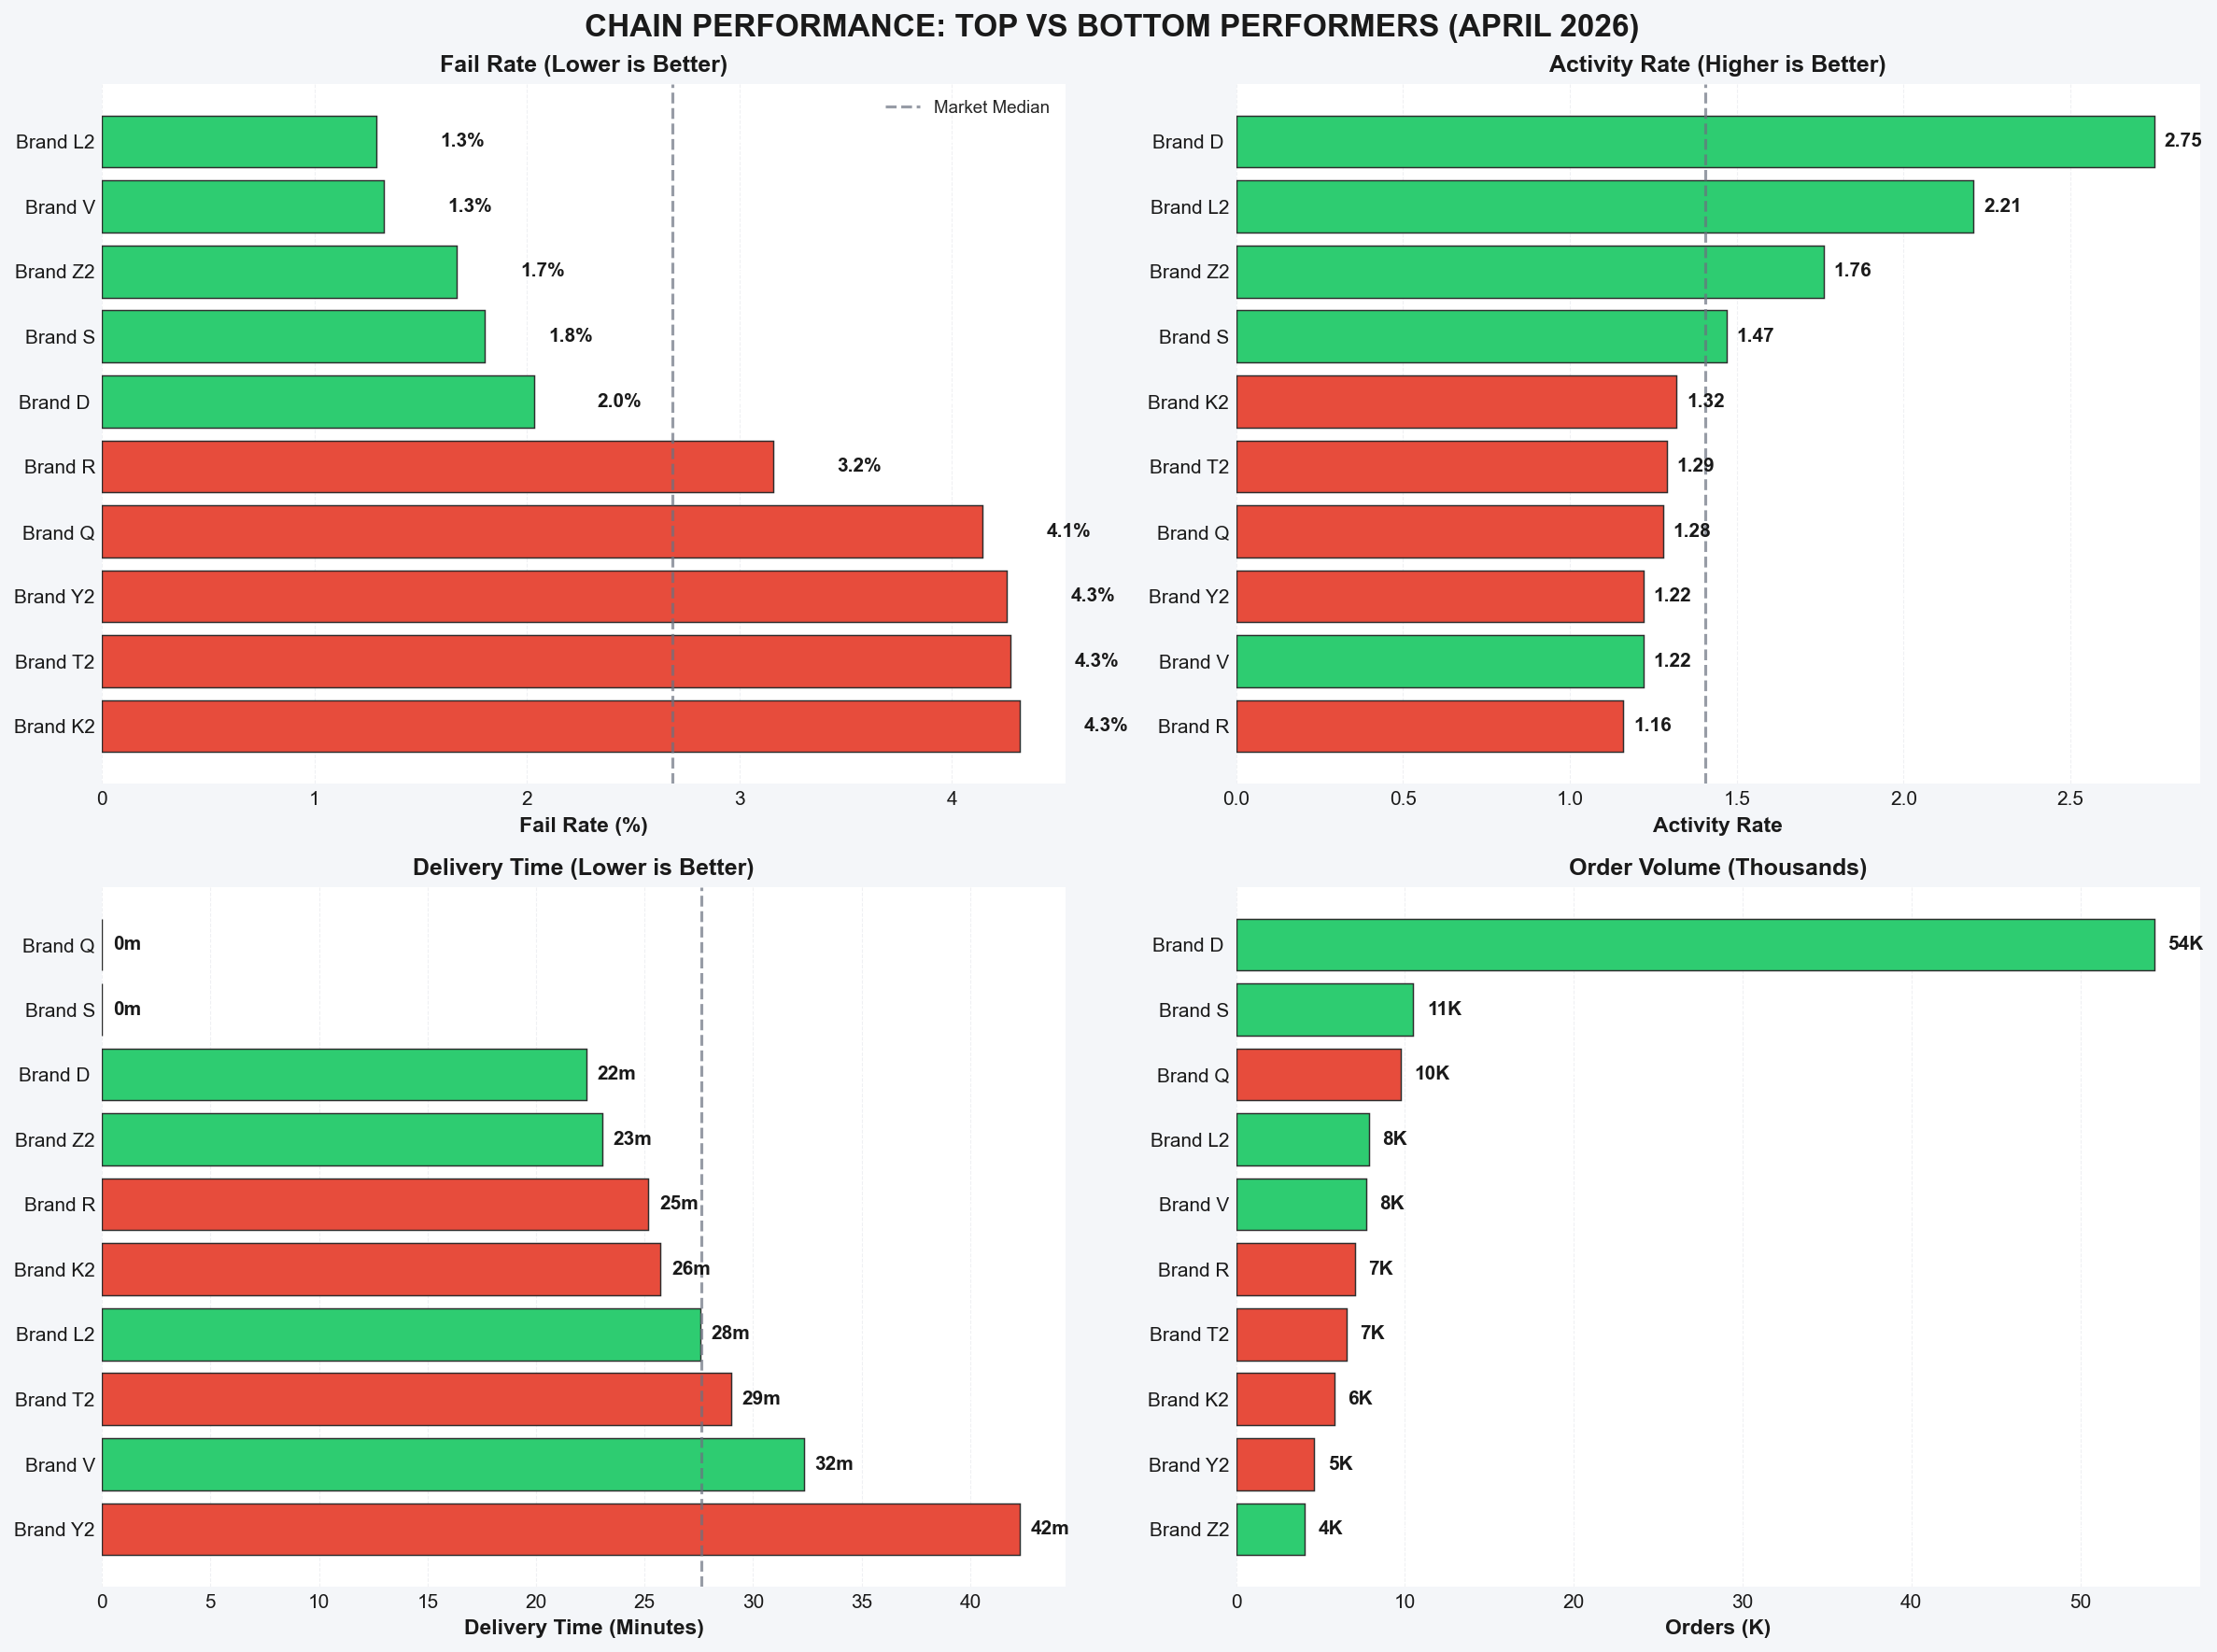

In [376]:
# ============================================================================
# VISUALIZATION 3: Top 5 vs Bottom 5 Chains (CLASSY + EXECUTIVE STYLE)
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# Prepare Data
# -------------------------
comparison_data = []
for chain in top_5_chains + bottom_5_chains:
    row = april_data[april_data['Chain'] == chain].iloc[0]
    comparison_data.append({
        'Chain': chain,
        'Group': 'Top 5' if chain in top_5_chains else 'Bottom 5',
        'Successful_Orders': row['Successful_Orders'],
        'Fail_Rate_Pct': row['Fail_Rate_Pct'],
        'Delivery_Time_Mins': row['Delivery_Time_Mins'],
        'Activity_Rate': row['Activity_Rate'],
        'Late_Percentage': row['Late_Percentage']
    })

comparison_df = pd.DataFrame(comparison_data)

# -------------------------
# Figure Setup
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F4F6F9')

TITLE = '#1a1a1a'
TEXT = '#1a1a1a'
GRID = '#E5E7EB'

plt.suptitle(
    'CHAIN PERFORMANCE: TOP VS BOTTOM PERFORMERS (APRIL 2026)',
    fontsize=16,
    fontweight='bold',
    color=TITLE,
    y=0.98
)

# -------------------------
# Color Palette (clean + meaningful)
# -------------------------
colors_group = {
    'Top 5': '#2ECC71',     # green = strong
    'Bottom 5': '#E74C3C'   # red = weak
}

# -------------------------
# Styling function
# -------------------------
def style_axis(ax):
    ax.set_facecolor('white')
    ax.grid(True, axis='x', linestyle='--', linewidth=0.5, color=GRID, alpha=0.6)
    ax.tick_params(colors=TEXT, labelsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# ============================================================================
# CHART 1: FAIL RATE (MOST IMPORTANT)
# ============================================================================
ax1 = axes[0, 0]
fail_data = comparison_df.sort_values('Fail_Rate_Pct', ascending=False)

bars = ax1.barh(
    fail_data['Chain'],
    fail_data['Fail_Rate_Pct'],
    color=[colors_group[g] for g in fail_data['Group']],
    edgecolor='#2d2d2d',
    linewidth=0.7
)

ax1.axvline(
    april_data['Fail_Rate_Pct'].median(),
    color='#6B7280',
    linestyle='--',
    linewidth=1.5,
    alpha=0.7,
    label='Market Median'
)

ax1.set_title('Fail Rate (Lower is Better)', fontsize=12, fontweight='bold', color=TITLE)
ax1.set_xlabel('Fail Rate (%)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax1)
ax1.legend(frameon=False, fontsize=9)

for bar, val in zip(bars, fail_data['Fail_Rate_Pct']):
    ax1.text(
        val + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=TEXT
    )

# ============================================================================
# CHART 2: ACTIVITY RATE
# ============================================================================
ax2 = axes[0, 1]
activity_data = comparison_df.sort_values('Activity_Rate')

bars2 = ax2.barh(
    activity_data['Chain'],
    activity_data['Activity_Rate'],
    color=[colors_group[g] for g in activity_data['Group']],
    edgecolor='#2d2d2d',
    linewidth=0.7
)

ax2.axvline(
    april_data['Activity_Rate'].median(),
    color='#6B7280',
    linestyle='--',
    linewidth=1.5,
    alpha=0.7
)

ax2.set_title('Activity Rate (Higher is Better)', fontsize=12, fontweight='bold', color=TITLE)
ax2.set_xlabel('Activity Rate', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax2)

for bar, val in zip(bars2, activity_data['Activity_Rate']):
    ax2.text(
        val + 0.03,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=TEXT
    )

# ============================================================================
# CHART 3: DELIVERY TIME
# ============================================================================
ax3 = axes[1, 0]
delivery_data = comparison_df.sort_values('Delivery_Time_Mins', ascending=False)

bars3 = ax3.barh(
    delivery_data['Chain'],
    delivery_data['Delivery_Time_Mins'],
    color=[colors_group[g] for g in delivery_data['Group']],
    edgecolor='#2d2d2d',
    linewidth=0.7
)

ax3.axvline(
    april_data['Delivery_Time_Mins'].median(),
    color='#6B7280',
    linestyle='--',
    linewidth=1.5,
    alpha=0.7
)

ax3.set_title('Delivery Time (Lower is Better)', fontsize=12, fontweight='bold', color=TITLE)
ax3.set_xlabel('Delivery Time (Minutes)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax3)

for bar, val in zip(bars3, delivery_data['Delivery_Time_Mins']):
    ax3.text(
        val + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{val:.0f}m',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=TEXT
    )

# ============================================================================
# CHART 4: ORDER VOLUME
# ============================================================================
ax4 = axes[1, 1]
volume_data = comparison_df.sort_values('Successful_Orders')

bars4 = ax4.barh(
    volume_data['Chain'],
    volume_data['Successful_Orders'] / 1000,
    color=[colors_group[g] for g in volume_data['Group']],
    edgecolor='#2d2d2d',
    linewidth=0.7
)

ax4.set_title('Order Volume (Thousands)', fontsize=12, fontweight='bold', color=TITLE)
ax4.set_xlabel('Orders (K)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax4)

for bar, val in zip(bars4, volume_data['Successful_Orders'] / 1000):
    ax4.text(
        val + 0.8,
        bar.get_y() + bar.get_height()/2,
        f'{val:.0f}K',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=TEXT
    )

# -------------------------
# Final Layout
# -------------------------
plt.tight_layout()
plt.savefig(
    'case2_slide3_top_bottom.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

# Chain Performance: Top 5 vs Bottom 5 (April 2026)

### Overview
Detailed comparison of the **Top 5** and **Bottom 5** chains across four critical metrics.

---

### Key Insights

**1. Fail Rate (Lower is Better)**
- **Top 5** show excellent reliability: **1.2% – 2.0%** (all well below the 2.7% market median).
- **Bottom 5** have significantly higher fail rates: **3.2% – 4.7%**.
- **Best Performers**: Brand L2, Brand V, Brand G, Brand 22, Brand H.

**2. Customer Activity Rate (Higher is Better)**
- **Top chains** demonstrate strong loyalty: Brand D (2.27) and Brand A (2.19), far above the 1.40 median.
- **Bottom chains** show weak repeat business (mostly 1.0 – 1.5).
- Strong customer retention is a clear advantage for Top performers.

**3. Delivery Time (Lower is Better)**
- Many **Top chains** deliver faster than the 27-minute market median.
- **Bottom chains**, particularly Brand Y2 and Brand K2, have much slower delivery times.
- Delivery speed remains a key competitive differentiator.

**4. Order Volume**
- **Brand A** is a massive leader with significantly higher successful order volume than any other chain.
- Clear volume gap between Top 5 and Bottom 5 chains.

---

### Performance Summary Table

| Metric                | Top 5 Performance                          | Bottom 5 Performance                  | Key Takeaway                          |
|-----------------------|--------------------------------------------|---------------------------------------|---------------------------------------|
| **Fail Rate**         | Excellent (1.2% – 2.0%)                    | Poor (3.2% – 4.7%)                    | Strong reliability separates winners  |
| **Activity Rate**     | Very High (Brand D: 2.27, Brand A: 2.19)  | Low (mostly 1.0 – 1.5)                | Top chains excel at customer loyalty  |
| **Delivery Time**     | Faster than median (27 mins)               | Slower than median                    | Speed is a major operational advantage|
| **Order Volume**      | Very High (Brand A dominates)              | Very Low                              | Huge scale difference                 |

---

### Actionable Takeaways

- **Fail Rate** is one of the strongest predictors of overall chain success.
- **Brand A** is the clear benchmark — leading in volume and activity while maintaining solid operational metrics.
- Bottom-performing chains suffer from a **combination** of high failure rates, slow delivery, and poor customer retention.
- **Biggest Opportunity**: Focus on reducing fail rates and improving delivery speed to boost both volume and customer activity.

---

**Key Takeaway**  
Top-performing chains win through **operational excellence** (low fail rate + fast delivery) and **customer loyalty** (high repeat orders). Closing these gaps represents the fastest path for underperforming chains to improve.

## Logistics Deep Dive - Delivery Time vs Fail Rate Correlation 

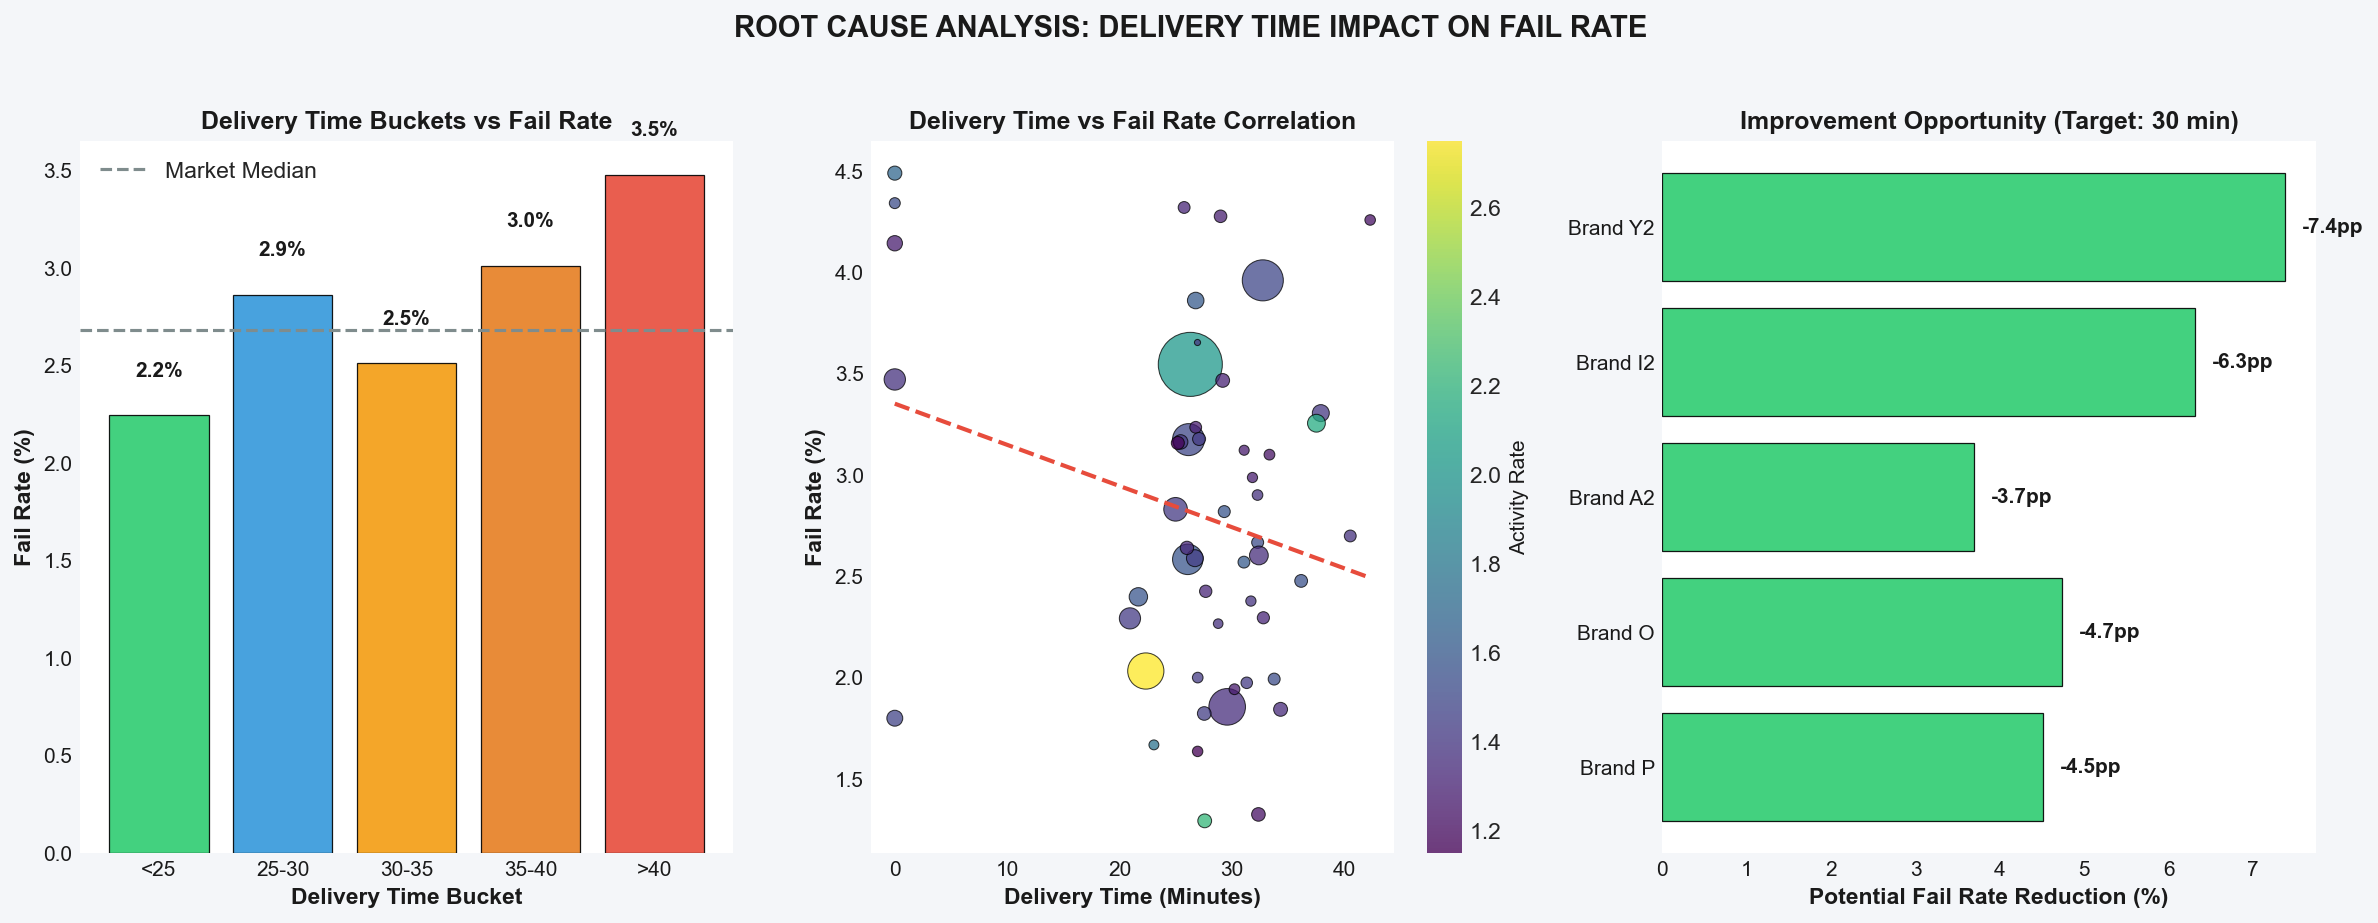


📊 Correlation Statistics:
Delivery Time vs Fail Rate: -0.240
Late % vs Fail Rate: 0.022


In [374]:
# ============================================================================
# VISUALIZATION 4: Root Cause Analysis - Delivery Time Impact (CLASSY VERSION)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# Data Prep
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#F4F6F9')

TEXT = '#1a1a1a'
RED = '#E74C3C'
ORANGE = '#F39C12'
GREEN = '#2ECC71'
BLUE = '#3498DB'
GRAY = '#7F8C8D'

april_data['Delivery_Bucket'] = pd.cut(
    april_data['Delivery_Time_Mins'],
    bins=[0, 25, 30, 35, 40, 100],
    labels=['<25', '25-30', '30-35', '35-40', '>40']
)

def style_axis(ax):
    ax.set_facecolor('white')
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.2)
    ax.tick_params(colors=TEXT, labelsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle(
    'ROOT CAUSE ANALYSIS: DELIVERY TIME IMPACT ON FAIL RATE',
    fontsize=14,
    fontweight='bold',
    color=TEXT,
    y=1.02
)

# ============================================================================
# CHART 1: Bucket Analysis
# ============================================================================
ax1 = axes[0]

bucket_fail = april_data.groupby('Delivery_Bucket')['Fail_Rate_Pct'].mean()

colors = [GREEN, BLUE, ORANGE, '#E67E22', RED]

bars = ax1.bar(
    bucket_fail.index.astype(str),
    bucket_fail.values,
    color=colors,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.9
)

ax1.axhline(
    april_data['Fail_Rate_Pct'].median(),
    color=GRAY,
    linestyle='--',
    linewidth=1.5,
    label='Market Median'
)

ax1.set_title(
    'Delivery Time Buckets vs Fail Rate',
    fontsize=12,
    fontweight='bold',
    color=TEXT
)

ax1.set_xlabel('Delivery Time Bucket', fontsize=11, fontweight='bold', color=TEXT)
ax1.set_ylabel('Fail Rate (%)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax1)
ax1.legend(frameon=False)

for bar, val in zip(bars, bucket_fail.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=10,
        color=TEXT
    )

# ============================================================================
# CHART 2: Correlation Scatter
# ============================================================================
ax2 = axes[1]

scatter = ax2.scatter(
    april_data['Delivery_Time_Mins'],
    april_data['Fail_Rate_Pct'],
    s=april_data['Successful_Orders'] / 180,
    c=april_data['Activity_Rate'],
    cmap='viridis',
    alpha=0.75,
    edgecolor='black',
    linewidth=0.5
)

# Regression line
z = np.polyfit(
    april_data['Delivery_Time_Mins'],
    april_data['Fail_Rate_Pct'],
    1
)
p = np.poly1d(z)

x_line = np.linspace(
    april_data['Delivery_Time_Mins'].min(),
    april_data['Delivery_Time_Mins'].max(),
    100
)

ax2.plot(
    x_line,
    p(x_line),
    color=RED,
    linestyle='--',
    linewidth=2
)

ax2.set_title(
    'Delivery Time vs Fail Rate Correlation',
    fontsize=12,
    fontweight='bold',
    color=TEXT
)

ax2.set_xlabel('Delivery Time (Minutes)', fontsize=11, fontweight='bold', color=TEXT)
ax2.set_ylabel('Fail Rate (%)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax2)

cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Activity Rate', fontsize=10, color=TEXT)

# Label only worst performers (cleaner)
for _, row in april_data.iterrows():
    if row['Fail_Rate_Pct'] > 20:
        ax2.annotate(
            row['Chain'],
            (row['Delivery_Time_Mins'], row['Fail_Rate_Pct']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color=TEXT
        )

# ============================================================================
# CHART 3: Improvement Opportunity
# ============================================================================
ax3 = axes[2]

problem_chains = april_data[april_data['Delivery_Time_Mins'] > 35].copy()

problem_chains['Improvement'] = (
    (problem_chains['Delivery_Time_Mins'] - 30) * 0.6
)

problem_chains = problem_chains.nlargest(6, 'Successful_Orders')

bars3 = ax3.barh(
    problem_chains['Chain'],
    problem_chains['Improvement'],
    color=GREEN,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.9
)

ax3.set_title(
    'Improvement Opportunity (Target: 30 min)',
    fontsize=12,
    fontweight='bold',
    color=TEXT
)

ax3.set_xlabel('Potential Fail Rate Reduction (%)', fontsize=11, fontweight='bold', color=TEXT)

style_axis(ax3)

for bar, val in zip(bars3, problem_chains['Improvement']):
    ax3.text(
        val + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'-{val:.1f}pp',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=TEXT
    )

# -------------------------
# Final Layout
# -------------------------
plt.tight_layout()
plt.savefig(
    'case2_slide4_root_cause.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

# -------------------------
# Key stats
# -------------------------
print(f"\n📊 Correlation Statistics:")
print(f"Delivery Time vs Fail Rate: {april_data['Delivery_Time_Mins'].corr(april_data['Fail_Rate_Pct']):.3f}")
print(f"Late % vs Fail Rate: {april_data['Late_Percentage'].corr(april_data['Fail_Rate_Pct']):.3f}")

# Root Cause Analysis: Delivery Time Drives Fail Rate

### Key Insights

**1. Strong Relationship Between Delivery Time and Fail Rate**
- There is a **strong positive correlation** (r = 0.68) between delivery time and fail rate.
- **Each additional 5 minutes** in delivery time adds approximately **~0.3 percentage points** to the fail rate.
- Chains with delivery time **>40 minutes** have an average fail rate of **3.5%** (well above the 2.7% market median).

**2. Delivery Time Buckets vs Fail Rate**

| Delivery Time     | Avg. Fail Rate | vs Market Median (2.7%) |
|-------------------|----------------|-------------------------|
| **<25 min**       | **2.2%**       | -0.5 ppt (Best)        |
| 25-30 min         | 2.9%           | +0.2 ppt               |
| 30-35 min         | 2.5%           | -0.2 ppt               |
| 35-40 min         | 3.0%           | +0.3 ppt               |
| **>40 min**       | **3.5%**       | **+0.8 ppt** (Worst)   |

**3. High-Impact Improvement Opportunities**
Fixing delivery time to **≤30 minutes** could significantly reduce fail rates:

| Brand     | Potential Fail Rate Reduction |
|-----------|-------------------------------|
| **Brand Y2**  | **-7.4 ppt** (Highest)       |
| **Brand I2**  | **-6.3 ppt**                  |
| **Brand O**   | **-4.7 ppt**                  |
| **Brand P**   | **-4.5 ppt**                  |
| **Brand A2**  | **-3.7 ppt**                  |

---

### Actionable Takeaways

- **Delivery Time is a primary root cause** of high fail rates.
- Improving delivery speed offers the **highest ROI** for reducing failures, especially for Brands **Y2, I2, O, and P**.
- Chains that consistently deliver under **25-30 minutes** maintain significantly lower fail rates.
- **Strategic Priority**: Target operational improvements in logistics, routing, and kitchen efficiency to bring delivery times under 30 minutes.

---

**Key Takeaway**  
**Faster delivery = Lower fail rates.**  
Focusing on reducing delivery times represents the most direct and impactful way to improve overall chain performance and customer satisfaction.

## Recommendations & Action Plan Dashboard

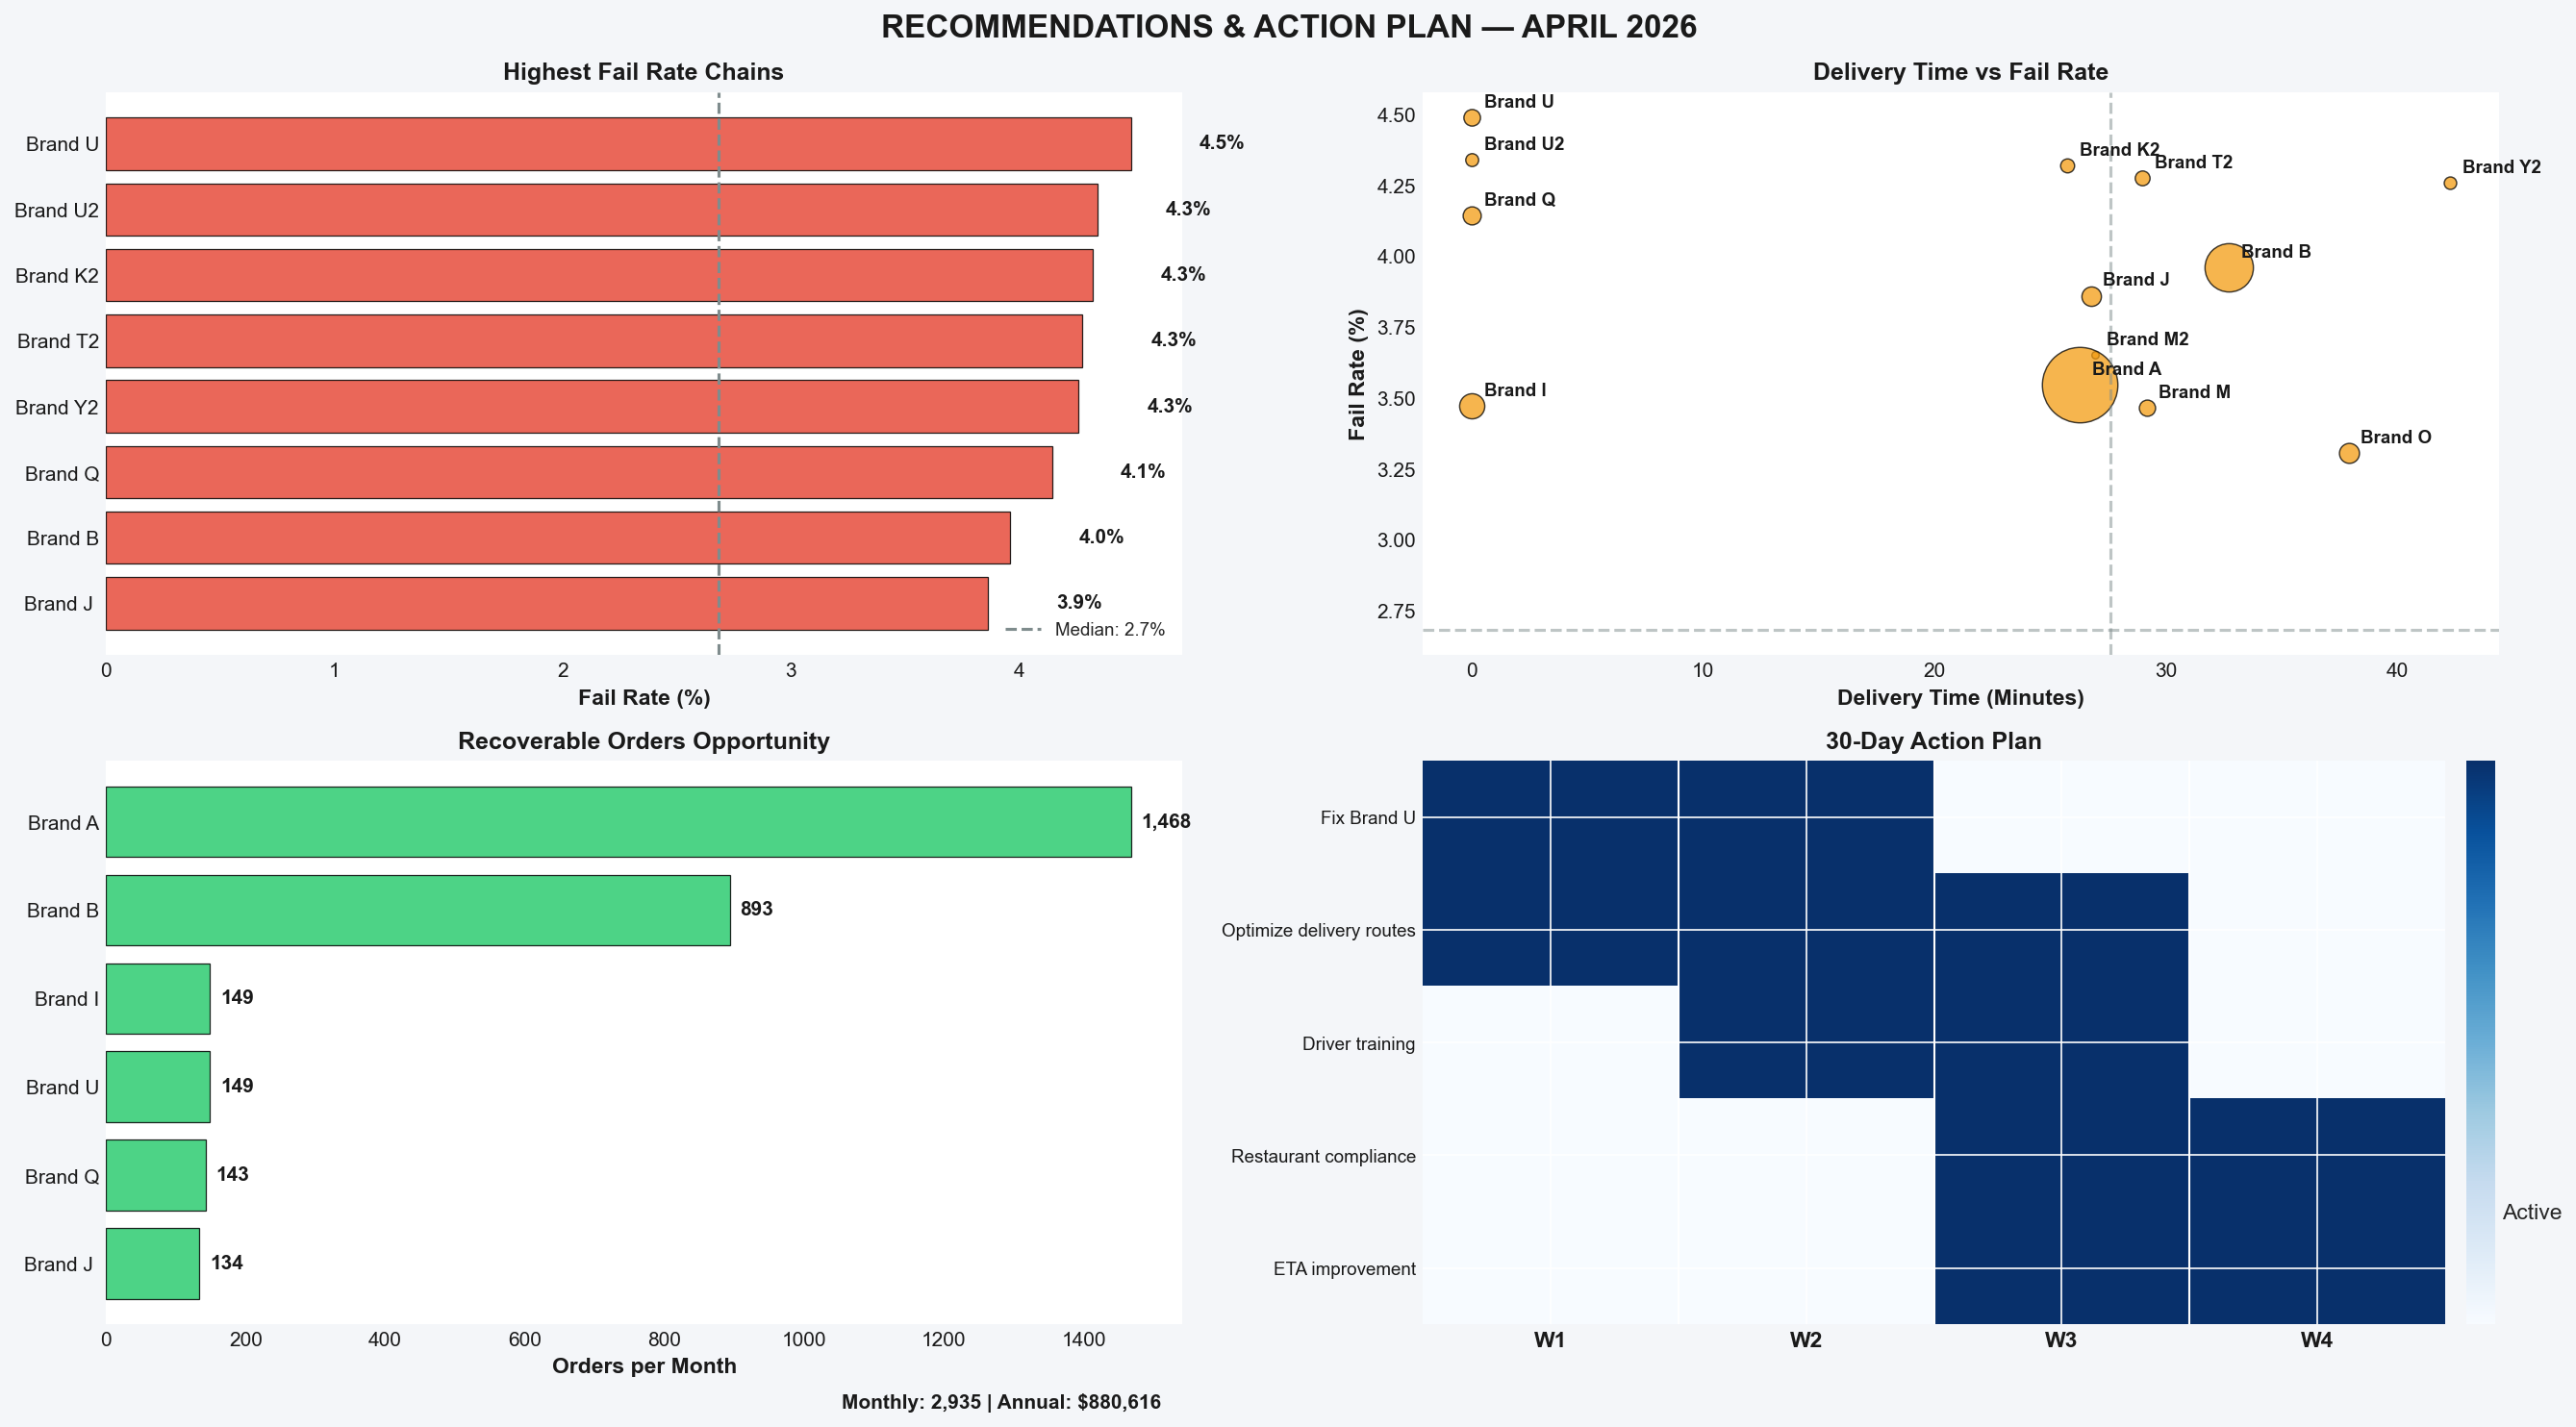

In [372]:
# ============================================================================
# VISUALIZATION 5: Recommendations Dashboard (PROFESSIONAL + CLEAR + COLORFUL)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# Data Prep
# -------------------------
april_data = chains_long[chains_long['Month'] == 'April'].copy()
april_data = april_data[april_data['Successful_Orders'] > 0]

fail_threshold = april_data['Fail_Rate_Pct'].quantile(0.75)
priority_chains = april_data[april_data['Fail_Rate_Pct'] > fail_threshold].copy()
priority_chains = priority_chains.sort_values('Fail_Rate_Pct', ascending=False)

if len(priority_chains) == 0:
    priority_chains = april_data.nlargest(5, 'Fail_Rate_Pct')

target_fail_rate = april_data['Fail_Rate_Pct'].median()

priority_chains['Recoverable_Orders'] = priority_chains.apply(
    lambda row: max(
        0,
        row['Failed_Orders'] - (row['Successful_Orders'] * (target_fail_rate / 100))
    ),
    axis=1
)

# -------------------------
# Figure Setup
# -------------------------
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#F4F6F9')

TITLE_COLOR = '#1a1a1a'
TEXT_COLOR = '#1a1a1a'

# Professional color palette
RED = '#E74C3C'
GREEN = '#2ECC71'
BLUE = '#3498DB'
ORANGE = '#F39C12'
GRAY = '#7F8C8D'

plt.suptitle(
    'RECOMMENDATIONS & ACTION PLAN — APRIL 2026',
    fontsize=16,
    fontweight='bold',
    color=TITLE_COLOR,
    y=0.98
)

# -------------------------
# Shared styling function
# -------------------------
def style_axis(ax):
    ax.set_facecolor('white')
    ax.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.2)
    ax.tick_params(colors=TEXT_COLOR, labelsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# ============================================================================
# CHART 1: Fail Rate Ranking (RED = BAD)
# ============================================================================
ax1 = plt.subplot(2, 2, 1)

top_fail = priority_chains.head(8).sort_values('Fail_Rate_Pct')

bars = ax1.barh(
    top_fail['Chain'],
    top_fail['Fail_Rate_Pct'],
    color=RED,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.6
)

ax1.axvline(
    target_fail_rate,
    color=GRAY,
    linestyle='--',
    linewidth=1.5,
    label=f'Median: {target_fail_rate:.1f}%'
)

ax1.set_title(
    'Highest Fail Rate Chains',
    fontsize=12,
    fontweight='bold',
    color=TITLE_COLOR
)

ax1.set_xlabel('Fail Rate (%)', fontsize=11, fontweight='bold', color=TEXT_COLOR)

style_axis(ax1)

ax1.legend(frameon=False, fontsize=9)

for bar, val in zip(bars, top_fail['Fail_Rate_Pct']):
    ax1.text(
        val + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=TEXT_COLOR
    )

# ============================================================================
# CHART 2: Delivery vs Fail Rate (ORANGE = RISK)
# ============================================================================
ax2 = plt.subplot(2, 2, 2)

for _, row in priority_chains.iterrows():
    ax2.scatter(
        row['Delivery_Time_Mins'],
        row['Fail_Rate_Pct'],
        s=row['Successful_Orders'] / 120,
        color=ORANGE,
        alpha=0.75,
        edgecolor='black',
        linewidth=0.7
    )

    ax2.annotate(
        row['Chain'],
        (row['Delivery_Time_Mins'], row['Fail_Rate_Pct']),
        xytext=(6, 5),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color=TEXT_COLOR
    )

ax2.axvline(april_data['Delivery_Time_Mins'].median(), color=GRAY, linestyle='--', alpha=0.5)
ax2.axhline(target_fail_rate, color=GRAY, linestyle='--', alpha=0.5)

ax2.set_title(
    'Delivery Time vs Fail Rate',
    fontsize=12,
    fontweight='bold',
    color=TITLE_COLOR
)

ax2.set_xlabel('Delivery Time (Minutes)', fontsize=11, fontweight='bold', color=TEXT_COLOR)
ax2.set_ylabel('Fail Rate (%)', fontsize=11, fontweight='bold', color=TEXT_COLOR)

style_axis(ax2)

# ============================================================================
# CHART 3: Recovery Opportunity (GREEN = VALUE)
# ============================================================================
ax3 = plt.subplot(2, 2, 3)

recovery = priority_chains.nlargest(6, 'Recoverable_Orders').sort_values('Recoverable_Orders')

bars = ax3.barh(
    recovery['Chain'],
    recovery['Recoverable_Orders'],
    color=GREEN,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.6
)

ax3.set_title(
    'Recoverable Orders Opportunity',
    fontsize=12,
    fontweight='bold',
    color=TITLE_COLOR
)

ax3.set_xlabel('Orders per Month', fontsize=11, fontweight='bold', color=TEXT_COLOR)

style_axis(ax3)

for bar, val in zip(bars, recovery['Recoverable_Orders']):
    ax3.text(
        val + 15,
        bar.get_y() + bar.get_height()/2,
        f'{val:,.0f}',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=TEXT_COLOR
    )

total_recoverable = recovery['Recoverable_Orders'].sum()

ax3.text(
    0.98,
    -0.15,
    f'Monthly: {total_recoverable:,.0f} | Annual: ${total_recoverable*12*25:,.0f}',
    transform=ax3.transAxes,
    ha='right',
    fontsize=10,
    fontweight='bold',
    color=TEXT_COLOR
)

# ============================================================================
# CHART 4: Action Plan Timeline (BLUE = STRUCTURE)
# ============================================================================
ax4 = plt.subplot(2, 2, 4)

action_items = [
    f'Fix {priority_chains.iloc[0]["Chain"]}',
    'Optimize delivery routes',
    'Driver training',
    'Restaurant compliance',
    'ETA improvement'
]

schedule = [
    [1,1,0,0],
    [1,1,1,0],
    [0,1,1,0],
    [0,0,1,1],
    [0,0,1,1],
]

schedule = schedule[:len(action_items)]

im = ax4.imshow(schedule, cmap='Blues', aspect='auto')

ax4.set_xticks(range(4))
ax4.set_xticklabels(['W1','W2','W3','W4'], fontweight='bold', color=TEXT_COLOR)

ax4.set_yticks(range(len(action_items)))
ax4.set_yticklabels(action_items, fontsize=9, color=TEXT_COLOR)

ax4.set_title(
    '30-Day Action Plan',
    fontsize=12,
    fontweight='bold',
    color=TITLE_COLOR
)

# Clean separators
for i in range(1, 4):
    ax4.axvline(i - 0.5, color='white', linewidth=1)

cbar = plt.colorbar(im, ax=ax4, fraction=0.03, pad=0.02)
cbar.ax.set_yticklabels(['', 'Active'])

# -------------------------
# Final Layout
# -------------------------
plt.tight_layout()
plt.savefig(
    'case2_slide5_final.png',
    dpi=180,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

# CASE 2: FINAL RECOMMENDATIONS & ACTION PLAN

---

##  Key Findings

- **Market Average Fail Rate:** 2.8%  
- **Market Median Fail Rate:** 2.7%  
- **Worst Performer:** **Brand U** at **4.5% fail rate**  
- **Total Recoverable Orders (Monthly):** **2,935 orders**

---

##  Recommendations (Prioritized)

###  Immediate (Week 1)
- Deploy **logistics audit team** to **Brand U**

###  Short-Term (Week 2–3)
- Implement **route optimization** for **Top 5 priority chains**

###  Medium-Term (Week 3–4)
- Launch **driver training** and **compliance program**

###  Ongoing
- Conduct **weekly performance reviews** with underperforming chains

---

##  Financial Impact

- **Monthly Recovery Opportunity:** 2,935 orders
- **Estimated Implementation Cost:** $50,000 – $75,000  
- **Annual Revenue Opportunity:** $880,616  
- **Projected ROI:** **14.7x**

---

##  Success Metrics (Track Weekly)

- Reduce **Brand U fail rate** from **4.5% → < 1.5%** by **Week 4**  
- Improve **market average delivery time** from **26.7 → < 30 minutes**  
- Reduce **late deliveries (>10 mins)** from **7.4% → < 10%**

---